In [1]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from build_finesat_dataset import build_finesat_dataset

DATASET_DIR = os.path.join('..', 'geometry-consistent-data')
FILENAME = "gc_c3.2_data1.json"
RTCM_PATH = os.path.join(os.getcwd(), "..", "..", "gnss-data-collection",
                         "window-experiment", "data", "samples")

with open(os.path.join(DATASET_DIR, FILENAME), 'r') as f:
    data = json.load(f)


# 1. Load the FineSat feature matrix and labels
window0_data_paths = []
window0 = data[0]
for i in range(0, len(window0)):
    window0_data_paths.append(os.path.join(RTCM_PATH, window0[i][0]))

window1_data_paths = []
window1 = data[1]
for i in range(0, len(window1)):
    window1_data_paths.append(os.path.join(RTCM_PATH, window1[i][0]))

window2_data_paths = []
window2 = data[2]
for i in range(0, len(window2)):
    window2_data_paths.append(os.path.join(RTCM_PATH, window2[i][0]))

window3_data_paths = []
window3 = data[3]
for i in range(0, len(window3)):
    window3_data_paths.append(os.path.join(RTCM_PATH, window3[i][0]))

X0_fs, Y0_fs = build_finesat_dataset(window0_data_paths)
X1_fs, Y1_fs = build_finesat_dataset(window1_data_paths)
X2_fs, Y2_fs = build_finesat_dataset(window2_data_paths)
X3_fs, Y3_fs = build_finesat_dataset(window3_data_paths)


# 2. Encode labels ('m', 'push', 'star', etc.) into numbers
label_encoder_fs = LabelEncoder()
Y0_encoded_fs = label_encoder_fs.fit_transform(Y0_fs)
Y1_encoded_fs = label_encoder_fs.fit_transform(Y1_fs)
Y2_encoded_fs = label_encoder_fs.fit_transform(Y2_fs)
Y3_encoded_fs = label_encoder_fs.fit_transform(Y3_fs)

# 3. Train/Test Split (80% training, 20% testing)
X0_train_fs, X0_test_fs, Y0_train_fs, Y0_test_fs = train_test_split(
    X0_fs, Y0_encoded_fs, test_size=0.2, random_state=42, stratify=Y0_encoded_fs
)
X1_train_fs, X1_test_fs, Y1_train_fs, Y1_test_fs = train_test_split(
    X1_fs, Y1_encoded_fs, test_size=0.2, random_state=42, stratify=Y1_encoded_fs
)
X2_train_fs, X2_test_fs, Y2_train_fs, Y2_test_fs = train_test_split(
    X2_fs, Y2_encoded_fs, test_size=0.2, random_state=42, stratify=Y2_encoded_fs
)
X3_train_fs, X3_test_fs, Y3_train_fs, Y3_test_fs = train_test_split(
    X3_fs, Y3_encoded_fs, test_size=0.2, random_state=42, stratify=Y3_encoded_fs
)

# 4. Scale features (Mean=0, Variance=1)
scaler_fs = StandardScaler()
X0_train_scaled_fs = scaler_fs.fit_transform(X0_train_fs)
X0_test_scaled_fs = scaler_fs.transform(X0_test_fs)

X1_train_scaled_fs = scaler_fs.fit_transform(X1_train_fs)
X1_test_scaled_fs = scaler_fs.transform(X1_test_fs)

X2_train_scaled_fs = scaler_fs.fit_transform(X2_train_fs)
X2_test_scaled_fs = scaler_fs.transform(X2_test_fs)

X3_train_scaled_fs = scaler_fs.fit_transform(X3_train_fs)
X3_test_scaled_fs = scaler_fs.transform(X3_test_fs)

# 5. Train the SVM
print("\nTraining FineSat SVM...")
svm_model0_fs = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model0_fs.fit(X0_train_scaled_fs, Y0_train_fs)

svm_model1_fs = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model1_fs.fit(X1_train_scaled_fs, Y1_train_fs)

svm_model2_fs = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model2_fs.fit(X2_train_scaled_fs, Y2_train_fs)

svm_model3_fs = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model3_fs.fit(X3_train_scaled_fs, Y3_train_fs)

# 6. Predict & Evaluate
Y0_pred_fs = svm_model0_fs.predict(X0_test_scaled_fs)
accuracy0_fs = accuracy_score(Y0_test_fs, Y0_pred_fs)

Y1_pred_fs = svm_model1_fs.predict(X1_test_scaled_fs)
accuracy1_fs = accuracy_score(Y1_test_fs, Y1_pred_fs)

Y2_pred_fs = svm_model2_fs.predict(X2_test_scaled_fs)
accuracy2_fs = accuracy_score(Y2_test_fs, Y2_pred_fs)

Y3_pred_fs = svm_model3_fs.predict(X3_test_scaled_fs)
accuracy3_fs = accuracy_score(Y3_test_fs, Y3_pred_fs)

print(f"\n🏆 FineSat Pipeline 0 Accuracy: {accuracy0_fs * 100:.2f}%\n")
print(f"\n🏆 FineSat Pipeline 1 Accuracy: {accuracy1_fs * 100:.2f}%\n")
print(f"\n🏆 FineSat Pipeline 2 Accuracy: {accuracy2_fs * 100:.2f}%\n")
print(f"\n🏆 FineSat Pipeline 3 Accuracy: {accuracy3_fs * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(Y0_test_fs, Y0_pred_fs, target_names=label_encoder_fs.classes_))
print(classification_report(Y1_test_fs, Y1_pred_fs, target_names=label_encoder_fs.classes_))
print(classification_report(Y2_test_fs, Y2_pred_fs, target_names=label_encoder_fs.classes_))
print(classification_report(Y3_test_fs, Y3_pred_fs, target_names=label_encoder_fs.classes_))

# 7. Plot Confusion Matrix
cm0_fs = confusion_matrix(Y0_test_fs, Y0_pred_fs)
cm1_fs = confusion_matrix(Y1_test_fs, Y1_pred_fs)
cm2_fs = confusion_matrix(Y2_test_fs, Y2_pred_fs)
cm3_fs = confusion_matrix(Y3_test_fs, Y3_pred_fs)

Processing 46 files for FINESAT Pipeline...

FineSat Dataset Built!
Feature Matrix (X) Shape: (46, 78)  -> (46 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (46,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 60 files for FINESAT Pipeline...

FineSat Dataset Built!
Feature Matrix (X) Shape: (60, 78)  -> (60 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (60,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 90 files for FINESAT Pipeline...


Unknown protocol header b'\xd3m'.
Unknown protocol header b'$\x04'.
Unknown protocol header b'\xd3\x80'.
Unknown protocol header b'$x'.
Unknown protocol header b'\xb5\xfa'.
Unknown protocol header b'\xd3D'.
Unknown protocol header b'\xd3w'.
Unknown protocol header b'$\x06'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5\xfa'.
Unknown protocol header b'$\xe2'.
Unknown protocol header b'$;'.
Unknown protocol header b'$\t'.
Unknown protocol header b'\xb5 '.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xd3\xd7'.
Unknown protocol header b'\xb5\x9f'.
Unknown protocol header b'\xd3Z'.
Unknown protocol header b'\xd3\xde'.
Unknown protocol header b'\xb5\x9b'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5^'.
Unknown protocol header b'\xd3\x9d'.
Serial stream terminated unexpectedly. 1874 bytes requested, 955 bytes returned.
Unknown protocol header b'$K'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x95'.
Unknown protocol heade


FineSat Dataset Built!
Feature Matrix (X) Shape: (90, 78)  -> (90 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (90,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 78 files for FINESAT Pipeline...


Unknown protocol header b'\xb5\x8b'.
Serial stream terminated unexpectedly. 170 bytes requested, 126 bytes returned.
Unknown protocol header b'$g'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5\x8a'.
Unknown protocol header b'\xb5\x97'.
Unknown protocol header b'\xd3\xed'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xd3\xf7'.
Unknown protocol header b'$0'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x05'.



FineSat Dataset Built!
Feature Matrix (X) Shape: (78, 78)  -> (78 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (78,)
Saved as ./X_finesat.npy and ./Y_finesat.npy

Training FineSat SVM...

🏆 FineSat Pipeline 0 Accuracy: 40.00%


🏆 FineSat Pipeline 1 Accuracy: 25.00%


🏆 FineSat Pipeline 2 Accuracy: 33.33%


🏆 FineSat Pipeline 3 Accuracy: 43.75%

Classification Report:
              precision    recall  f1-score   support

        m_W3       1.00      0.50      0.67         2
     push_W3       0.40      0.67      0.50         3
 pushpull_W3       0.33      0.33      0.33         3
     star_W3       0.00      0.00      0.00         1
 triangle_W3       0.00      0.00      0.00         1

    accuracy                           0.40        10
   macro avg       0.35      0.30      0.30        10
weighted avg       0.42      0.40      0.38        10

              precision    recall  f1-score   support

        m_W3       0.00      0.00      0.00         2
     push_W3       

/Users/sreehari_miniravi/Work/ResearchProjects/wifi2sat/gnss-data-collection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sreehari_miniravi/Work/ResearchProjects/wifi2sat/gnss-data-collection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sreehari_miniravi/Work/ResearchProjects/wifi2sat/gnss-data-collection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being se

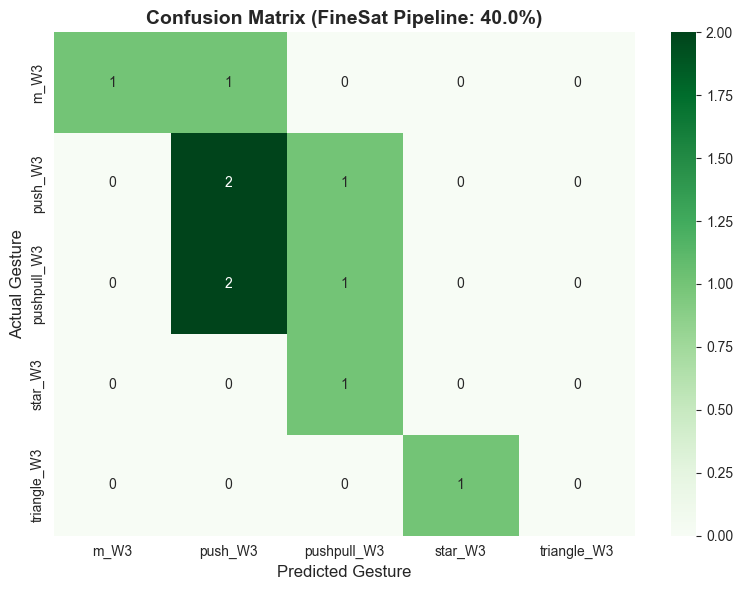

In [2]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm0_fs, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder_fs.classes_,
            yticklabels=label_encoder_fs.classes_)
plt.title(f"Confusion Matrix (FineSat Pipeline: {accuracy0_fs * 100:.1f}%)", fontsize=14, fontweight='bold')
plt.ylabel('Actual Gesture', fontsize=12)
plt.xlabel('Predicted Gesture', fontsize=12)
plt.tight_layout()
plt.show()

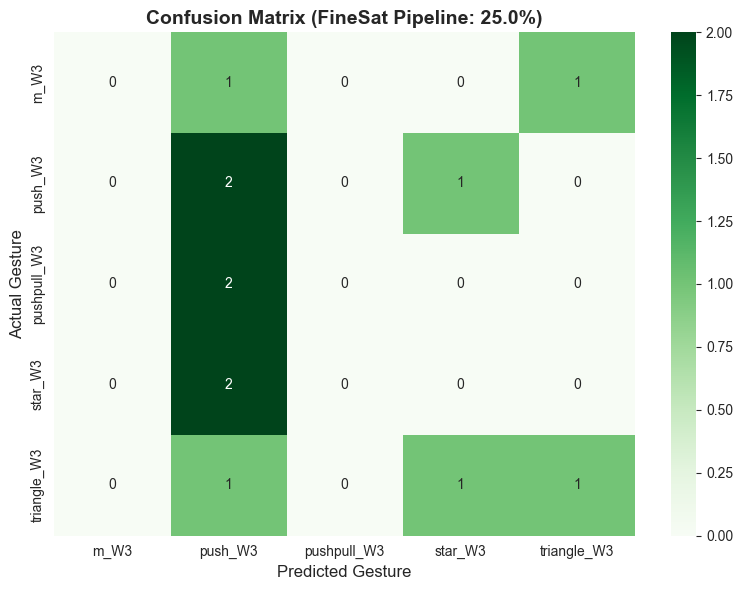

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm1_fs, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder_fs.classes_,
            yticklabels=label_encoder_fs.classes_)
plt.title(f"Confusion Matrix (FineSat Pipeline: {accuracy1_fs * 100:.1f}%)", fontsize=14, fontweight='bold')
plt.ylabel('Actual Gesture', fontsize=12)
plt.xlabel('Predicted Gesture', fontsize=12)
plt.tight_layout()
plt.show()

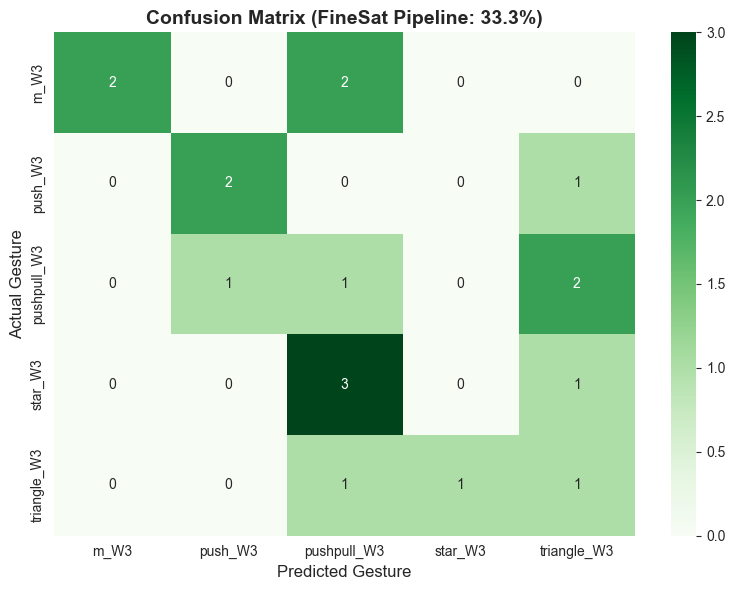

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm2_fs, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder_fs.classes_,
            yticklabels=label_encoder_fs.classes_)
plt.title(f"Confusion Matrix (FineSat Pipeline: {accuracy2_fs * 100:.1f}%)", fontsize=14, fontweight='bold')
plt.ylabel('Actual Gesture', fontsize=12)
plt.xlabel('Predicted Gesture', fontsize=12)
plt.tight_layout()
plt.show()

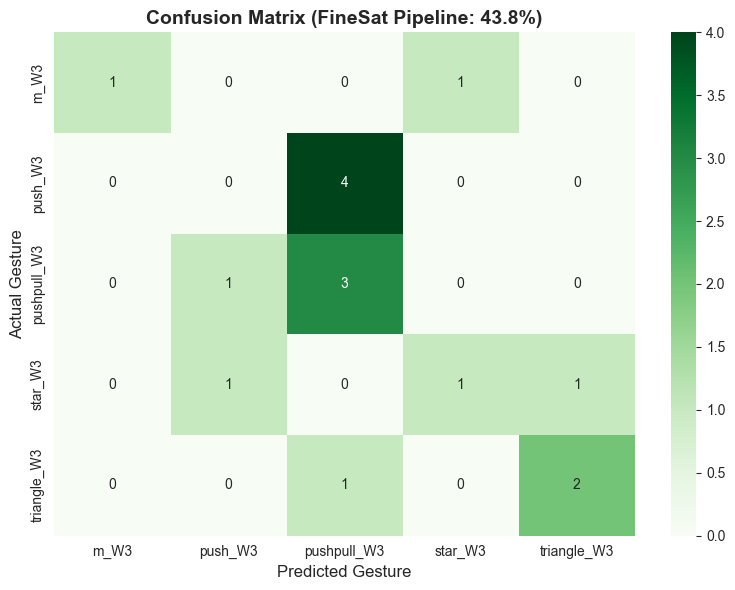

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm3_fs, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder_fs.classes_,
            yticklabels=label_encoder_fs.classes_)
plt.title(f"Confusion Matrix (FineSat Pipeline: {accuracy3_fs * 100:.1f}%)", fontsize=14, fontweight='bold')
plt.ylabel('Actual Gesture', fontsize=12)
plt.xlabel('Predicted Gesture', fontsize=12)
plt.tight_layout()
plt.show()